# 🔥 Project 3 — Correlation Heatmap & Pairwise Relationships
**Syntecxhub Data Science Internship | Week 2, Project 3**

---

## 📌 About This Project

Correlation analysis answers one of the most important questions in data science — **which variables move together?** If salary goes up, does performance go up too? If experience increases, does satisfaction change?

| Concept | Meaning |
|---|---|
| Pearson Correlation | Measures linear relationship between two numeric variables, ranges from -1 to +1 |
| +1 | Perfect positive relationship — both go up together |
| -1 | Perfect negative relationship — one goes up, other goes down |
| 0 | No linear relationship |
| Heatmap | Color-coded grid showing all correlations at once |
| Pairplot | Grid of scatter plots showing every variable pair simultaneously |

### This notebook covers:
1. Generating a realistic multi-feature dataset
2. Computing Pearson correlation matrix
3. Visualizing as a heatmap with masked upper triangle
4. Pairplots and scatter matrix for key variable pairs
5. Identifying and summarizing strongest relationships
6. Exporting all plots and a written summary

---

## 📦 Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import os
from datetime import datetime

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

os.makedirs("plots", exist_ok=True)
print(f"Seaborn:  {sns.__version__}")
print(f"Pandas:   {pd.__version__}")
print("Output folder 'plots/' ready ✅")

Seaborn:  0.13.2
Pandas:   2.3.3
Output folder 'plots/' ready ✅


---
## 🗂️ Step 0: Generate Dataset

We simulate a student academic performance dataset with 8 numeric features.
The correlations between features are designed to reflect realistic patterns — study hours and grades correlate positively, stress and sleep correlate negatively, and so on.

In [2]:
np.random.seed(42)
n = 500

# Base variables
study_hours   = np.random.normal(5, 1.5, n).clip(0, 12)
sleep_hours   = np.random.normal(7, 1, n).clip(4, 10)
stress_level  = 10 - sleep_hours * 0.6 + np.random.normal(0, 1, n)
stress_level  = stress_level.clip(1, 10)

# Correlated variables
attendance    = (study_hours * 5 + np.random.normal(50, 8, n)).clip(40, 100)
math_score    = (study_hours * 6 + sleep_hours * 1.5 - stress_level * 1.2
                 + np.random.normal(40, 8, n)).clip(30, 100)
science_score = (math_score * 0.75 + np.random.normal(15, 8, n)).clip(30, 100)
english_score = (study_hours * 4 + np.random.normal(50, 10, n)).clip(30, 100)
final_grade   = (math_score * 0.4 + science_score * 0.3
                 + english_score * 0.3 + np.random.normal(0, 3, n)).clip(30, 100)

df = pd.DataFrame({
    "study_hours":   np.round(study_hours, 1),
    "sleep_hours":   np.round(sleep_hours, 1),
    "stress_level":  np.round(stress_level, 1),
    "attendance":    np.round(attendance, 1),
    "math_score":    np.round(math_score, 1),
    "science_score": np.round(science_score, 1),
    "english_score": np.round(english_score, 1),
    "final_grade":   np.round(final_grade, 1),
})

df.to_csv("student_performance.csv", index=False)
print(f"Dataset shape: {df.shape}")
print(f"\nFeature means:")
print(df.mean().round(2))
print(f"\nSample data:")
df.head()

Dataset shape: (500, 8)

Feature means:
study_hours       5.01
sleep_hours       7.03
stress_level      5.89
attendance       75.29
math_score       73.41
science_score    70.23
english_score    69.85
final_grade      71.33
dtype: float64

Sample data:


,study_hours,sleep_hours,stress_level,attendance,math_score,science_score,english_score,final_grade
0,5.7,7.9,6.6,85.0,73.0,74.3,53.9,71.2
1,4.8,8.9,5.6,69.6,74.3,78.4,60.6,69.5
2,6.0,5.6,6.7,73.3,69.9,64.7,69.8,68.4
3,7.3,7.6,4.8,86.4,86.8,75.2,98.0,86.8
4,4.6,6.3,6.9,71.9,54.0,46.8,74.2,56.4


---
## 📐 Section 1: Pearson Correlation Matrix

### What is Pearson correlation?
The Pearson coefficient measures the **strength and direction of the linear relationship** between two variables.

- Values close to **+1** → strong positive relationship
- Values close to **-1** → strong negative relationship  
- Values close to **0** → little to no linear relationship

We compute it for all variable pairs at once using `.corr()`.

In [3]:
# Compute Pearson correlation matrix
corr_matrix = df.corr(method="pearson")

print("Pearson Correlation Matrix:")
print(corr_matrix.round(3))

Pearson Correlation Matrix:
               study_hours  sleep_hours  stress_level  attendance  math_score  \
study_hours          1.000       -0.074        -0.013       0.709       0.725   
sleep_hours         -0.074        1.000        -0.449      -0.066       0.134   
stress_level        -0.013       -0.449         1.000      -0.014      -0.215   
attendance           0.709       -0.066        -0.014       1.000       0.477   
math_score           0.725        0.134        -0.215       0.477       1.000   
science_score        0.553        0.132        -0.169       0.373       0.745   
english_score        0.508       -0.023        -0.064       0.345       0.397   
final_grade          0.711        0.084        -0.201       0.465       0.878   

               science_score  english_score  final_grade  
study_hours            0.553          0.508        0.711  
sleep_hours            0.132         -0.023        0.084  
stress_level          -0.169         -0.064       -0.201  
attend

---
## 🌡️ Section 2: Correlation Heatmap

### Why mask the upper triangle?
A correlation matrix is **symmetrical** — the correlation between A and B is identical to B and A.
Showing both halves is redundant. Masking the upper triangle removes the duplicate and makes the chart easier to read.

### Annotation
Each cell shows the exact correlation value so you can read precise numbers, not just colours.

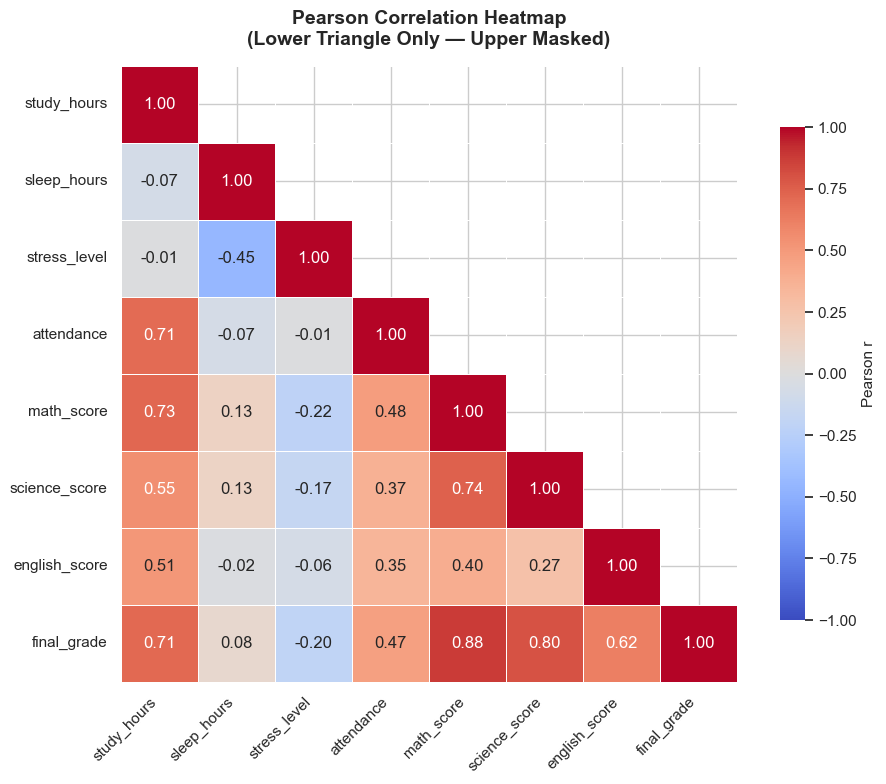

Saved → plots/01_correlation_heatmap.png


In [4]:
# --- Chart 1: Full correlation heatmap with masked upper triangle ---
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax
)

ax.set_title("Pearson Correlation Heatmap\n(Lower Triangle Only — Upper Masked)",
             fontweight="bold", pad=15, fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("plots/01_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/01_correlation_heatmap.png")

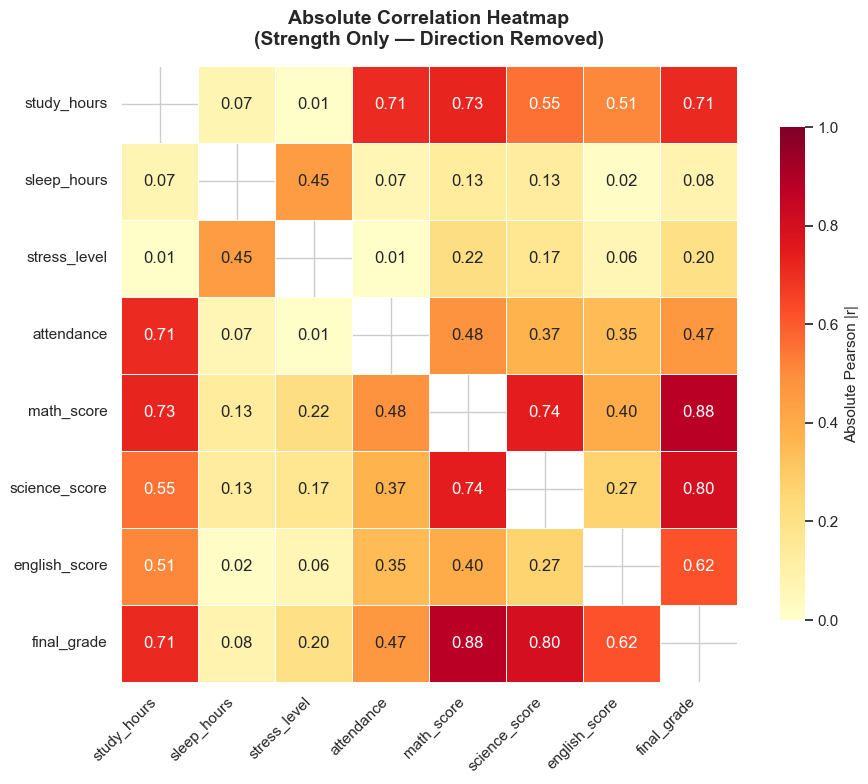

Saved → plots/02_absolute_correlation_heatmap.png


In [5]:
# --- Chart 2: Heatmap of absolute correlations — ranked by strength ---
abs_corr = corr_matrix.abs()
mask_diag = np.eye(len(abs_corr), dtype=bool)  # mask diagonal (self-correlation = 1)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    abs_corr,
    mask=mask_diag,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Absolute Pearson |r|"},
    ax=ax
)

ax.set_title("Absolute Correlation Heatmap\n(Strength Only — Direction Removed)",
             fontweight="bold", pad=15, fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("plots/02_absolute_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/02_absolute_correlation_heatmap.png")

---
## 🔵 Section 3: Pairplot / Scatter Matrix

### What is a pairplot?
A pairplot creates a **grid of scatter plots** — every variable plotted against every other variable.
The diagonal shows the distribution of each variable (histogram or KDE).

This is the fastest way to visually survey all pairwise relationships in a dataset at once — identifying linear trends, clusters and outliers across every combination.

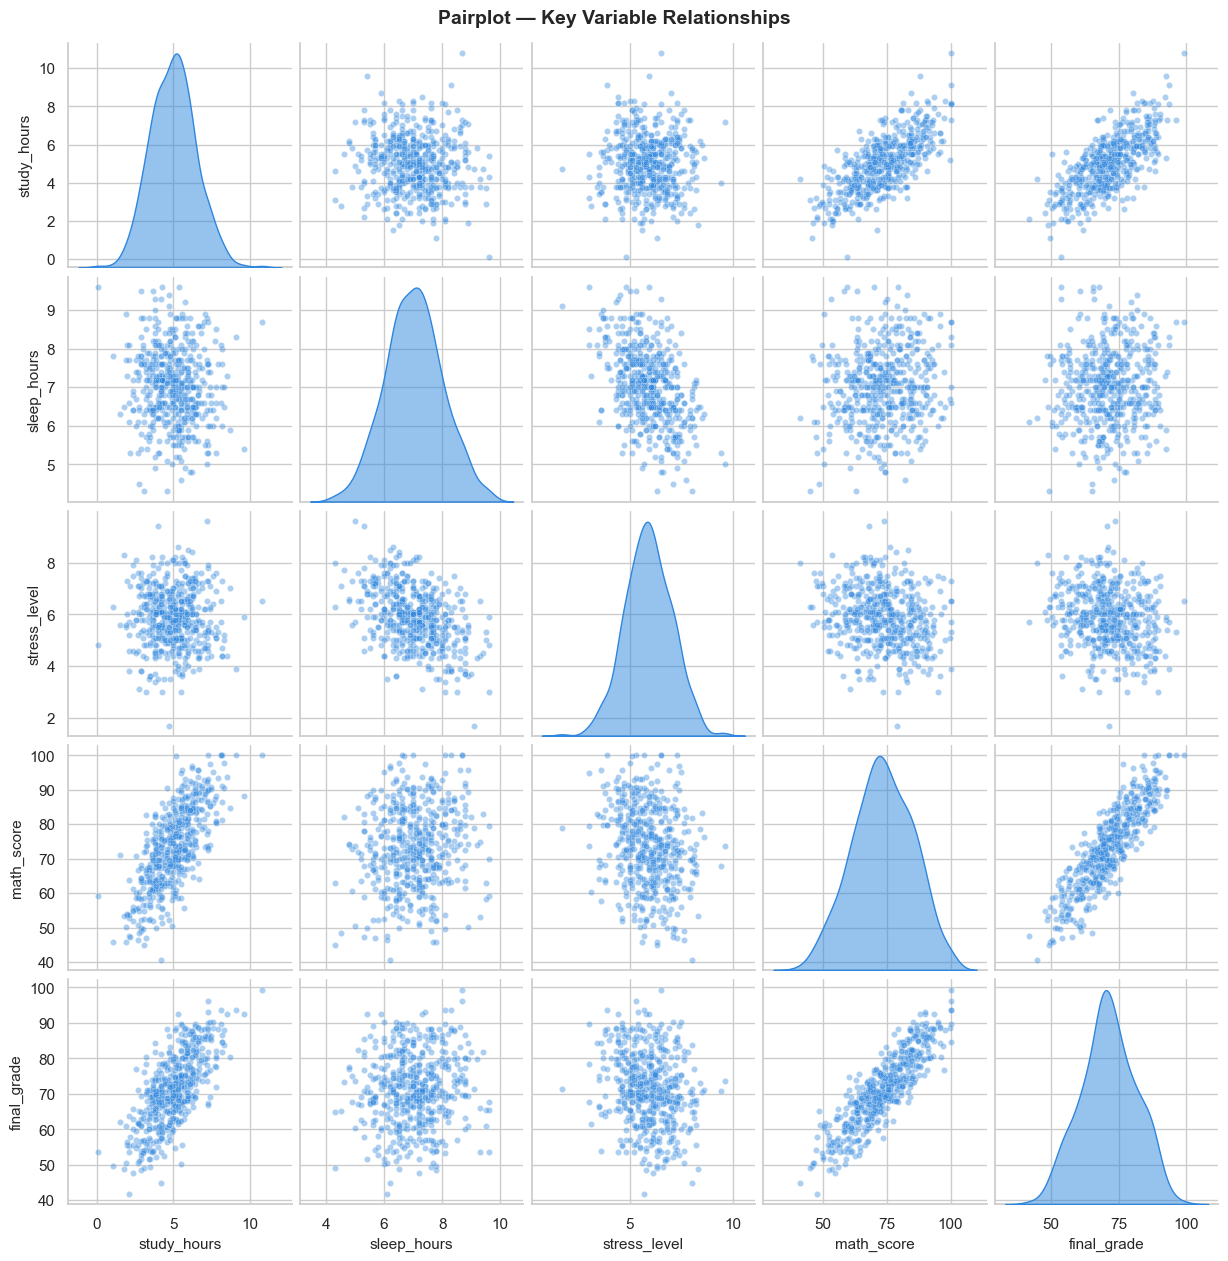

Saved → plots/03_pairplot_key_variables.png


In [6]:
# --- Chart 3: Full pairplot ---
# Use a subset of key variables to keep it readable
key_vars = ["study_hours", "sleep_hours", "stress_level", "math_score", "final_grade"]

fig = sns.pairplot(
    df[key_vars],
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 20, "color": "#2e86de"},
    diag_kws={"color": "#2e86de", "fill": True, "alpha": 0.5}
)

fig.figure.suptitle("Pairplot — Key Variable Relationships",
                    fontweight="bold", fontsize=14, y=1.01)

plt.savefig("plots/03_pairplot_key_variables.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/03_pairplot_key_variables.png")

---
## 📍 Section 4: Scatter Plots — Key Variable Pairs

After identifying the strongest correlations from the heatmap, we zoom in on the most interesting pairs with individual scatter plots and regression lines.

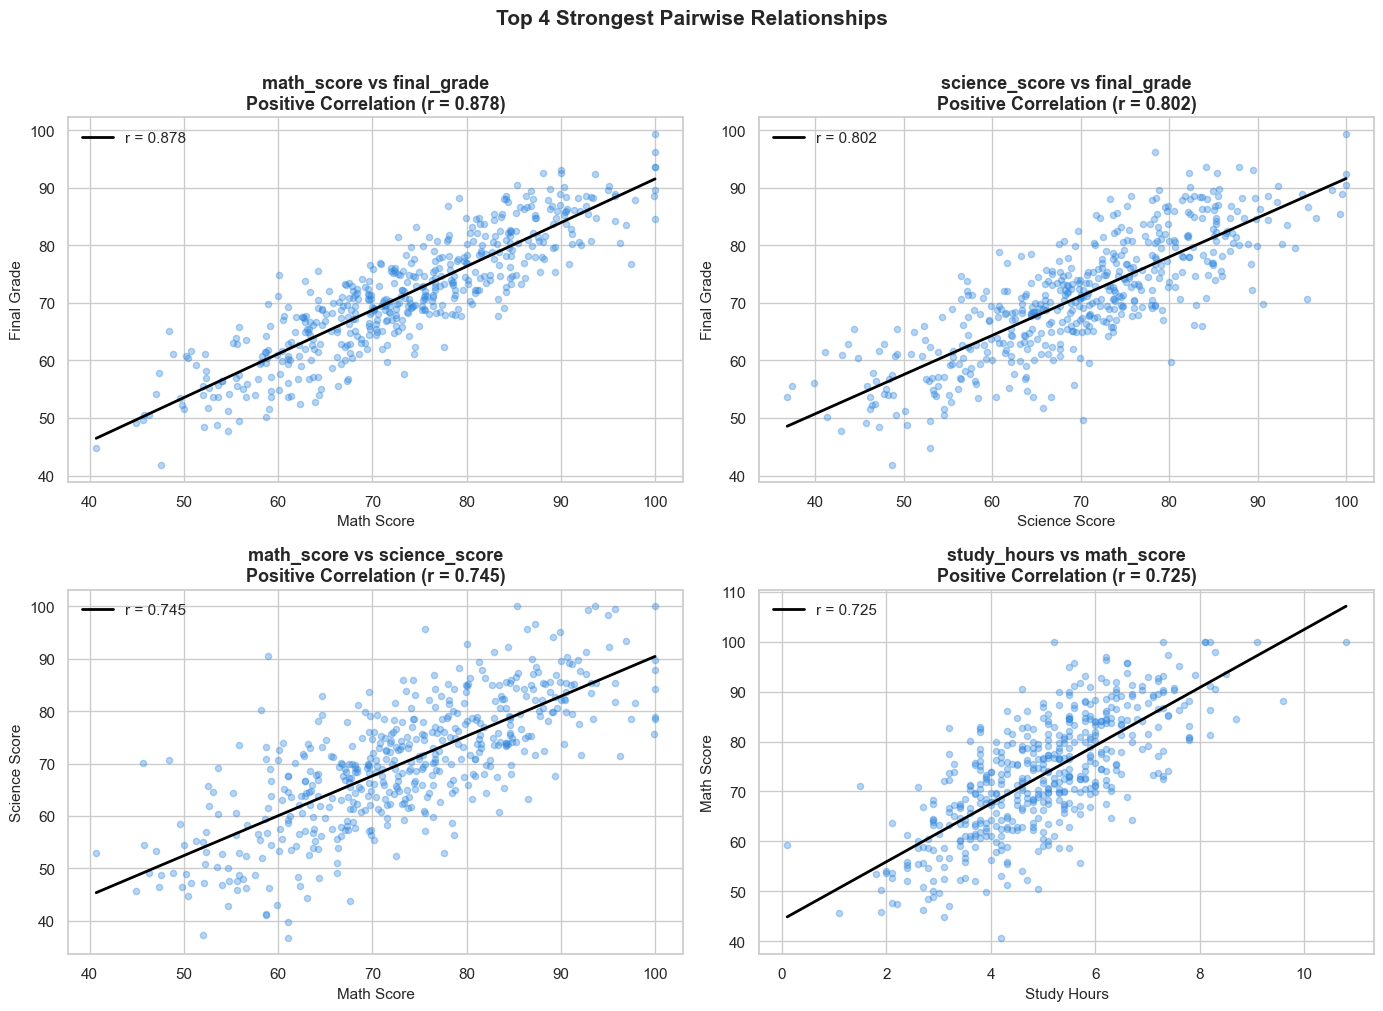

Saved → plots/04_top_correlation_scatter_plots.png


In [7]:
# --- Chart 4: Top 4 strongest correlations as scatter plots ---
# Find top pairs from correlation matrix
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col_a = corr_matrix.columns[i]
        col_b = corr_matrix.columns[j]
        r = corr_matrix.loc[col_a, col_b]
        corr_pairs.append((abs(r), r, col_a, col_b))

corr_pairs.sort(reverse=True)
top_pairs = corr_pairs[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Top 4 Strongest Pairwise Relationships",
             fontsize=15, fontweight="bold", y=1.01)

colors_pos = "#2e86de"
colors_neg = "#e84393"

for ax, (abs_r, r, col_a, col_b) in zip(axes.flatten(), top_pairs):
    color = colors_pos if r > 0 else colors_neg
    ax.scatter(df[col_a], df[col_b], alpha=0.35, s=20, color=color)

    # Regression line
    m, b, r_val, p_val, _ = stats.linregress(df[col_a], df[col_b])
    x_line = np.linspace(df[col_a].min(), df[col_a].max(), 100)
    ax.plot(x_line, m * x_line + b, color="black", linewidth=2,
            label=f"r = {r:.3f}")

    direction = "Positive" if r > 0 else "Negative"
    ax.set_title(f"{col_a} vs {col_b}\n{direction} Correlation (r = {r:.3f})",
                 fontweight="bold")
    ax.set_xlabel(col_a.replace("_", " ").title())
    ax.set_ylabel(col_b.replace("_", " ").title())
    ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("plots/04_top_correlation_scatter_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/04_top_correlation_scatter_plots.png")

---
## 📝 Section 5: Strongest Relationships Summary & Export

In [8]:
# --- Identify and print strongest positive and negative correlations ---
print("CORRELATION ANALYSIS SUMMARY")
print("=" * 55)

# All unique pairs
all_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col_a = corr_matrix.columns[i]
        col_b = corr_matrix.columns[j]
        r = corr_matrix.loc[col_a, col_b]
        strength = "Strong" if abs(r) >= 0.7 else "Moderate" if abs(r) >= 0.4 else "Weak"
        direction = "Positive" if r > 0 else "Negative"
        all_pairs.append({"Variable A": col_a, "Variable B": col_b,
                          "Pearson r": round(r, 3), "Strength": strength,
                          "Direction": direction})

pairs_df = pd.DataFrame(all_pairs).sort_values("Pearson r", key=abs, ascending=False)

print("\nTop 5 Strongest Relationships:")
print(pairs_df.head(5).to_string(index=False))

print("\nTop 5 Weakest Relationships:")
print(pairs_df.tail(5).to_string(index=False))

strongest_pos = pairs_df[pairs_df["Pearson r"] > 0].iloc[0]
strongest_neg = pairs_df[pairs_df["Pearson r"] < 0].iloc[0]

print(f"\nStrongest POSITIVE: {strongest_pos['Variable A']} vs {strongest_pos['Variable B']} (r = {strongest_pos['Pearson r']})")
print(f"Strongest NEGATIVE: {strongest_neg['Variable A']} vs {strongest_neg['Variable B']} (r = {strongest_neg['Pearson r']})")

CORRELATION ANALYSIS SUMMARY

Top 5 Strongest Relationships:
   Variable A    Variable B  Pearson r Strength Direction
   math_score   final_grade      0.878   Strong  Positive
science_score   final_grade      0.802   Strong  Positive
   math_score science_score      0.745   Strong  Positive
  study_hours    math_score      0.725   Strong  Positive
  study_hours   final_grade      0.711   Strong  Positive

Top 5 Weakest Relationships:
  Variable A    Variable B  Pearson r Strength Direction
 sleep_hours    attendance     -0.066     Weak  Negative
stress_level english_score     -0.064     Weak  Negative
 sleep_hours english_score     -0.023     Weak  Negative
stress_level    attendance     -0.014     Weak  Negative
 study_hours  stress_level     -0.013     Weak  Negative

Strongest POSITIVE: math_score vs final_grade (r = 0.878)
Strongest NEGATIVE: sleep_hours vs stress_level (r = -0.449)


In [9]:
# --- Export written summary ---
summary = f"""
CORRELATION ANALYSIS REPORT
Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
{'='*60}

DATASET
Features:  {list(df.columns)}
Rows:      {len(df)}

ALL PAIRWISE CORRELATIONS (sorted by strength)
{pairs_df.to_string(index=False)}

STRONGEST POSITIVE RELATIONSHIP
{strongest_pos['Variable A']} vs {strongest_pos['Variable B']}
Pearson r = {strongest_pos['Pearson r']}
Interpretation: As {strongest_pos['Variable A']} increases, {strongest_pos['Variable B']} tends to increase proportionally.
This is the strongest signal in the dataset and should be prioritized in any predictive model.

STRONGEST NEGATIVE RELATIONSHIP
{strongest_neg['Variable A']} vs {strongest_neg['Variable B']}
Pearson r = {strongest_neg['Pearson r']}
Interpretation: As {strongest_neg['Variable A']} increases, {strongest_neg['Variable B']} tends to decrease.
This inverse relationship is statistically meaningful and should be monitored.

CHART NOTES
- Heatmap upper triangle masked to remove redundant symmetric values
- Absolute heatmap removes direction to focus purely on relationship strength
- Pairplot diagonal shows KDE of each variable individually
- Regression lines added to scatter plots with r values annotated
- Blue dots = positive correlation, Pink dots = negative correlation
{'='*60}
"""

print(summary)

with open("correlation_summary.txt", "w") as f:
    f.write(summary)
print("Saved → correlation_summary.txt")


CORRELATION ANALYSIS REPORT
Generated: 2026-03-24 11:45:36

DATASET
Features:  ['study_hours', 'sleep_hours', 'stress_level', 'attendance', 'math_score', 'science_score', 'english_score', 'final_grade']
Rows:      500

ALL PAIRWISE CORRELATIONS (sorted by strength)
   Variable A    Variable B  Pearson r Strength Direction
   math_score   final_grade      0.878   Strong  Positive
science_score   final_grade      0.802   Strong  Positive
   math_score science_score      0.745   Strong  Positive
  study_hours    math_score      0.725   Strong  Positive
  study_hours   final_grade      0.711   Strong  Positive
  study_hours    attendance      0.709   Strong  Positive
english_score   final_grade      0.617 Moderate  Positive
  study_hours science_score      0.553 Moderate  Positive
  study_hours english_score      0.508 Moderate  Positive
   attendance    math_score      0.477 Moderate  Positive
   attendance   final_grade      0.465 Moderate  Positive
  sleep_hours  stress_level     -0.44

In [10]:
# --- Final chart inventory ---
plot_files = sorted([f for f in os.listdir("plots") if f.endswith(".png")])

print("All plots saved to /plots folder:")
for f in plot_files:
    size_kb = os.path.getsize(f"plots/{f}") / 1024
    print(f"  ✅ {f}  ({size_kb:.0f} KB)")

print(f"\n✅ Project 3 — Correlation Heatmap & Pairwise Relationships complete!")
print(f"   Total plots: {len(plot_files)}")

All plots saved to /plots folder:
  ✅ 01_correlation_heatmap.png  (130 KB)
  ✅ 02_absolute_correlation_heatmap.png  (148 KB)
  ✅ 03_pairplot_key_variables.png  (799 KB)
  ✅ 04_top_correlation_scatter_plots.png  (385 KB)

✅ Project 3 — Correlation Heatmap & Pairwise Relationships complete!
   Total plots: 4


---
## ✅ Summary

| Chart | Purpose |
|---|---|
| Correlation heatmap (lower triangle) | All pairwise correlations with sign and magnitude |
| Absolute correlation heatmap | Strength only — removes direction for simpler reading |
| Pairplot — key variables | Visual survey of all relationships simultaneously |
| Top 4 scatter plots with regression | Zoomed in on strongest pairs with trend lines |

### Key takeaways
- Pearson r only measures **linear** relationships — a value near 0 doesn't mean no relationship, just no *linear* one
- Always mask the upper triangle in heatmaps — the matrix is symmetric so the duplicate adds no information
- A strong correlation does not imply causation — two variables moving together may both be driven by a third hidden variable

---
*Syntecxhub Data Science Internship — Week 2, Project 3*